# Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_raw = pd.read_csv("hearinghope_raw.csv")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (5000, 24)


,record_id,user_id,visit_date,clinic_id,city,age,gender,pure_tone_avg_db,speech_recognition_score,hours_noisy_per_day,...,hearing_difficulty_score,followup_last_months,engages_exercises,tinnitus,prior_ear_infections,diabetes,smoking_status,consent,notes,recommendation
0,R00001,U37923,2025-11-01,HH-GK,Noida,57,M,34.2,52.1,4.5,...,4.0,NaN,0,1,0,0,Never,1,NaN,Maintain
1,R00002,U54445,2024-12-08,HH-DW,New Delhi,49,M,4.0,91.9,3.3,...,4.0,4.0,0,0,0,0,Never,1,NaN,Maintain
2,R00003,U18170,2025-06-28,HH-GK,New Delhi,85,M,53.9,52.1,1.6,...,NaN,18.0,0,0,0,0,Never,1,NaN,ConsiderHearingAid
3,R00004,U66317,2024-06-27,HH-ND,New Delhi,33,M,50.2,49.1,2.9,...,5.0,7.0,0,0,0,0,Former,1,NaN,ConsiderHearingAid
4,R00005,U29879,2025-09-12,HH-ND,New Delhi,28,M,28.9,69.1,NaN,...,2.0,18.0,1,0,0,0,Never,1,NaN,UseProtection


# Missing values visualization

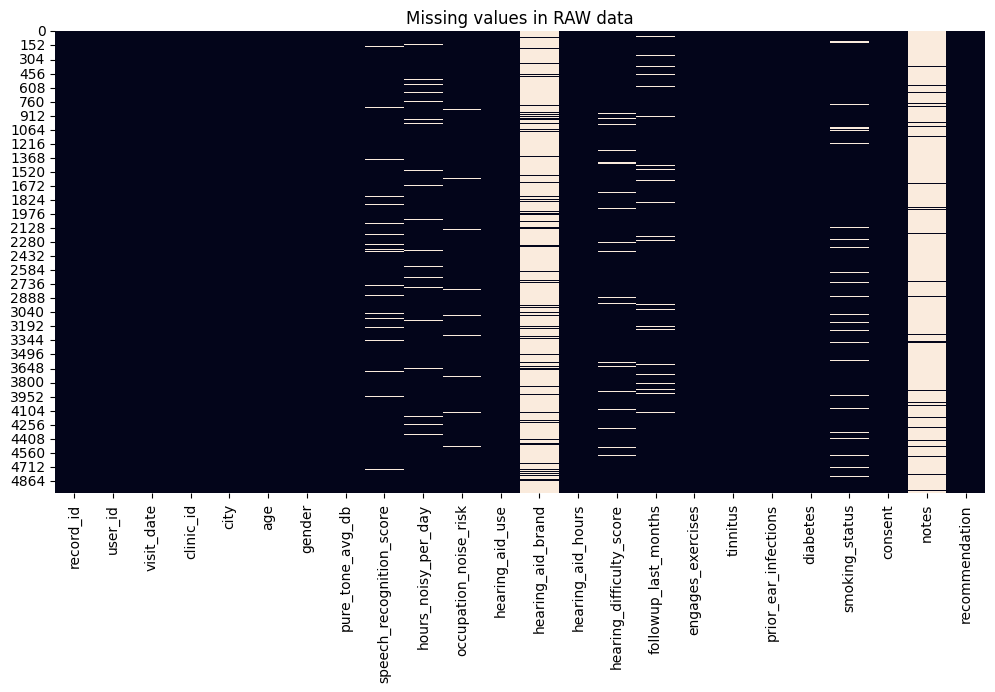

notes                       93.44
hearing_aid_brand           88.62
speech_recognition_score     5.00
hours_noisy_per_day          5.00
hearing_difficulty_score     5.00
followup_last_months         5.00
occupation_noise_risk        3.00
smoking_status               3.00
dtype: float64

In [2]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.heatmap(df_raw.isnull(), cbar=False)
plt.title("Missing values in RAW data")
plt.show()

missing_perc = (df_raw.isnull().sum()/len(df_raw))*100
missing_perc = missing_perc[missing_perc>0].sort_values(ascending=False)
missing_perc


# Clean data

In [3]:
df = df_raw.copy()

# Remove rows where consent ≠ 1 (privacy)
df = df[df["consent"]==1].copy()

# Drop text fields not used in model
df.drop(columns=["notes","record_id"], errors="ignore", inplace=True)

# Handle missing numerical values → median impute
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    df[c].fillna(df[c].median(), inplace=True)

# Handle missing categorical values → most frequent
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
for c in cat_cols:
    df[c].fillna(df[c].mode()[0], inplace=True)

print("After cleaning shape:", df.shape)
df.head()


After cleaning shape: (4860, 22)


C:\Users\sanje\AppData\Local\Temp\ipykernel_28124\3477971265.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[c].fillna(df[c].median(), inplace=True)
C:\Users\sanje\AppData\Local\Temp\ipykernel_28124\3477971265.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

,user_id,visit_date,clinic_id,city,age,gender,pure_tone_avg_db,speech_recognition_score,hours_noisy_per_day,occupation_noise_risk,...,hearing_aid_hours,hearing_difficulty_score,followup_last_months,engages_exercises,tinnitus,prior_ear_infections,diabetes,smoking_status,consent,recommendation
0,U37923,2025-11-01,HH-GK,Noida,57,M,34.2,52.1,4.5,Medium,...,0,4.0,10.0,0,1,0,0,Never,1,Maintain
1,U54445,2024-12-08,HH-DW,New Delhi,49,M,4.0,91.9,3.3,Medium,...,0,4.0,4.0,0,0,0,0,Never,1,Maintain
2,U18170,2025-06-28,HH-GK,New Delhi,85,M,53.9,52.1,1.6,Low,...,0,4.0,18.0,0,0,0,0,Never,1,ConsiderHearingAid
3,U66317,2024-06-27,HH-ND,New Delhi,33,M,50.2,49.1,2.9,Medium,...,0,5.0,7.0,0,0,0,0,Former,1,ConsiderHearingAid
4,U29879,2025-09-12,HH-ND,New Delhi,28,M,28.9,69.1,2.3,High,...,0,2.0,18.0,1,0,0,0,Never,1,UseProtection


In [4]:
df.isnull()

,user_id,visit_date,clinic_id,city,age,gender,pure_tone_avg_db,speech_recognition_score,hours_noisy_per_day,occupation_noise_risk,...,hearing_aid_hours,hearing_difficulty_score,followup_last_months,engages_exercises,tinnitus,prior_ear_infections,diabetes,smoking_status,consent,recommendation
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [5]:
df.shape

(4860, 22)

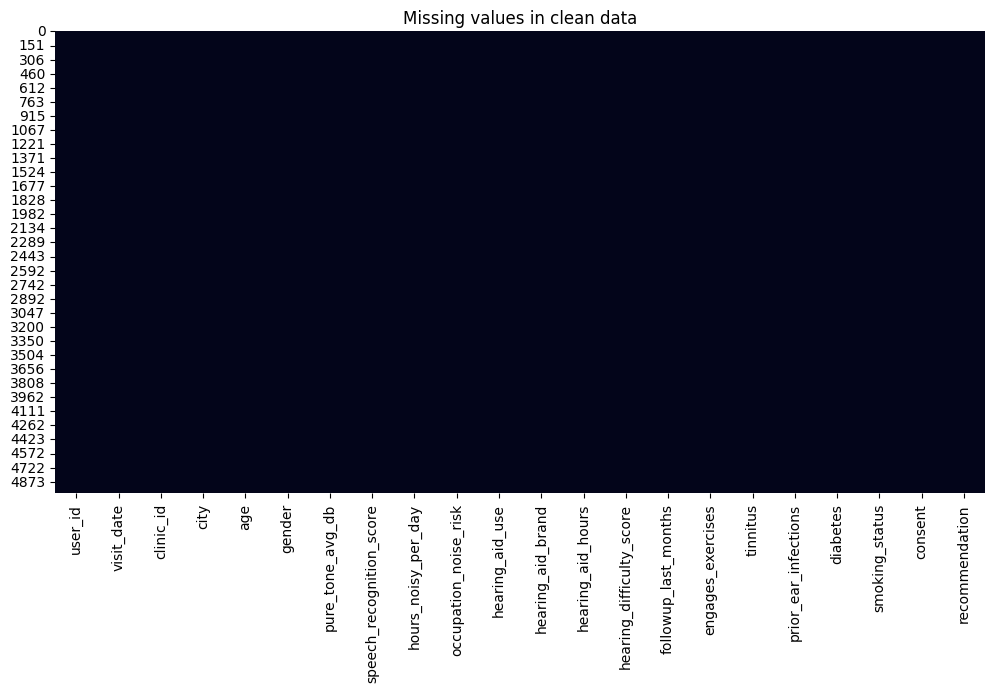

In [6]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing values in clean data")
plt.show()

# EDA

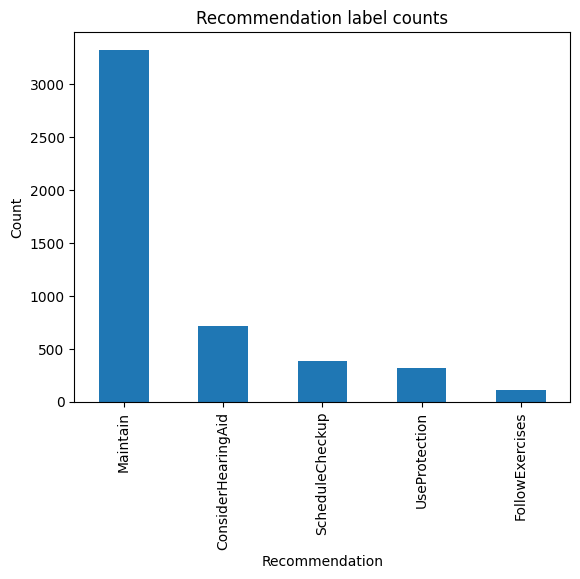

In [7]:
plt.figure()
df["recommendation"].value_counts().plot(kind="bar")
plt.title("Recommendation label counts")
plt.xlabel("Recommendation")
plt.ylabel("Count")
plt.show()


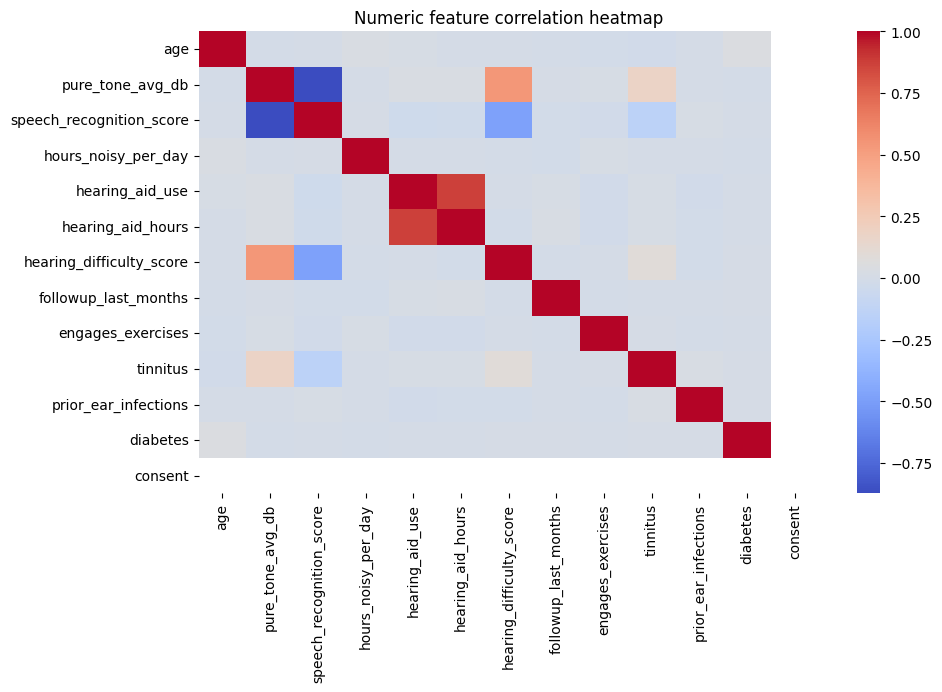

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=False, cmap="coolwarm")
plt.title("Numeric feature correlation heatmap")
plt.show()


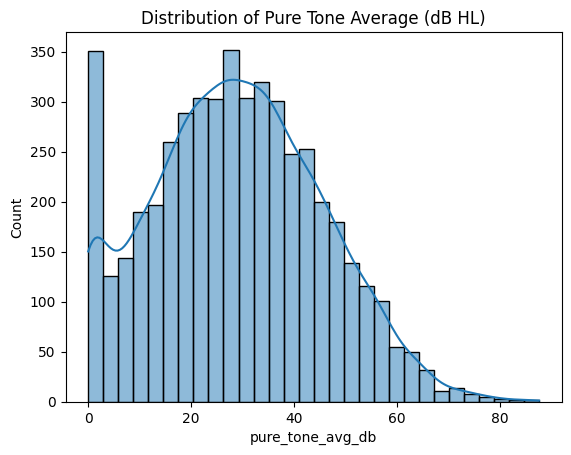

In [9]:
plt.figure()
sns.histplot(df["pure_tone_avg_db"], bins=30, kde=True)
plt.title("Distribution of Pure Tone Average (dB HL)")
plt.show()


# Feature preparation

In [10]:
target = "recommendation"
drop_from_features = ["user_id","visit_date","consent"]
X = df.drop(columns=[target]+[c for c in drop_from_features if c in df.columns])
y = df[target]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical:", cat_cols)
print("Numerical:", num_cols)


Categorical: ['clinic_id', 'city', 'gender', 'occupation_noise_risk', 'hearing_aid_brand', 'smoking_status']
Numerical: ['age', 'pure_tone_avg_db', 'speech_recognition_score', 'hours_noisy_per_day', 'hearing_aid_use', 'hearing_aid_hours', 'hearing_difficulty_score', 'followup_last_months', 'engages_exercises', 'tinnitus', 'prior_ear_infections', 'diabetes']


# Encoding + Scaling (feature engineering)

In [11]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])



# Train-test split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Top-5 Models (accuracy + macro-F1)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


candidates = {
    "LogisticRegression": LogisticRegression(max_iter=1000, n_jobs=None),  # n_jobs not valid for LR in sklearn<1.6; keep default
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "SVC": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

results = []

for name, clf in candidates.items():
    pipe_model = Pipeline([
        ("prep", preprocess),
        ("model", clf)
    ])
    pipe_model.fit(X_train, y_train)
    y_pred = pipe_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    results.append({
        "model": name,
        "accuracy": acc,
        "f1_macro": f1m,
        "estimator": pipe_model  # keep fitted pipeline so we can reuse the best directly
    })

results_df = pd.DataFrame(results).sort_values(["f1_macro","accuracy"], ascending=False).reset_index(drop=True)
results_df


,model,accuracy,f1_macro,estimator
0,GradientBoosting,0.991770,0.986266,"(ColumnTransformer(transformers=[('num',\n ..."
1,RandomForest,0.987654,0.973864,"(ColumnTransformer(transformers=[('num',\n ..."
2,SVC,0.935185,0.870856,"(ColumnTransformer(transformers=[('num',\n ..."
3,LogisticRegression,0.941358,0.859651,"(ColumnTransformer(transformers=[('num',\n ..."
4,KNN,0.851852,0.667100,"(ColumnTransformer(transformers=[('num',\n ..."


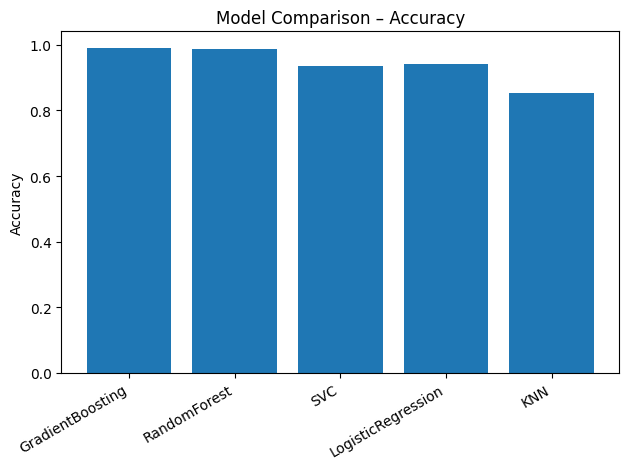

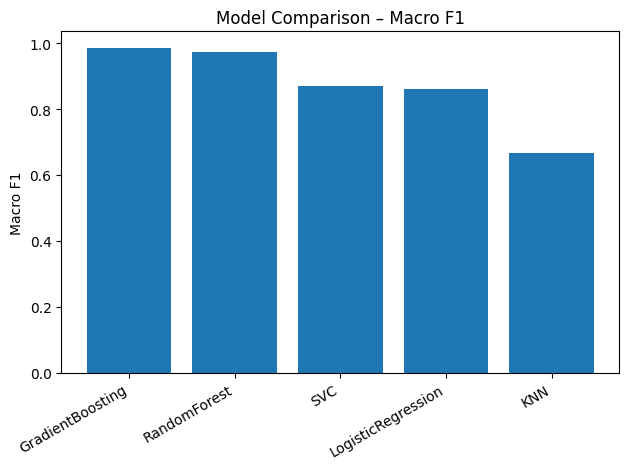

In [14]:
plt.figure()
plt.bar(results_df["model"], results_df["accuracy"])
plt.title("Model Comparison – Accuracy")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(results_df["model"], results_df["f1_macro"])
plt.title("Model Comparison – Macro F1")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Macro F1")
plt.tight_layout()
plt.show()


In [15]:
best_row = results_df.iloc[0]
best_name = best_row["model"]
best_pipe = best_row["estimator"]

print("Best model (by Macro-F1):", best_name)
y_pred_best = best_pipe.predict(X_test)

print("\nClassification Report (best):")
print(classification_report(y_test, y_pred_best))


Best model (by Macro-F1): GradientBoosting

Classification Report (best):
                    precision    recall  f1-score   support

ConsiderHearingAid       1.00      0.99      0.99       143
   FollowExercises       1.00      0.96      0.98        23
          Maintain       1.00      0.99      0.99       666
   ScheduleCheckup       0.95      1.00      0.97        76
     UseProtection       0.98      1.00      0.99        64

          accuracy                           0.99       972
         macro avg       0.99      0.99      0.99       972
      weighted avg       0.99      0.99      0.99       972



# Confusion Matrix

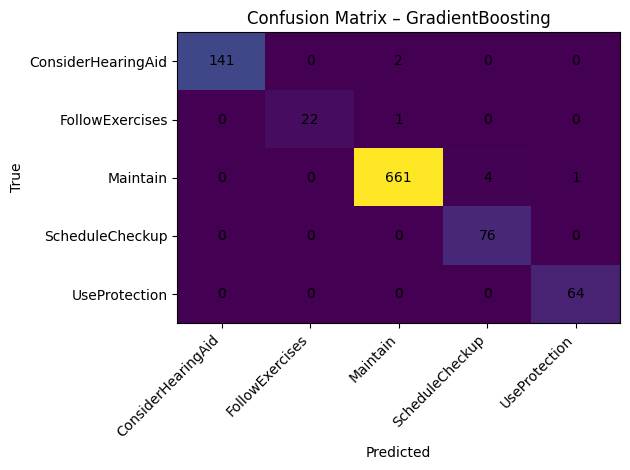

In [16]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_best, labels=labels)

plt.figure()
plt.imshow(cm, aspect='auto', interpolation='nearest')  # default colors
plt.title(f"Confusion Matrix – {best_name}")
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)
for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, int(val), ha='center', va='center')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


# 5-Fold Cross-Validation (accuracy + macro-F1)

In [17]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_validate(
    best_pipe, X, y,
    cv=cv,
    scoring={'acc': 'accuracy', 'f1': 'f1_macro'},
    n_jobs=-1
)

print("CV Accuracy:  mean=%.4f  std=%.4f" % (cv_scores['test_acc'].mean(), cv_scores['test_acc'].std()))
print("CV F1-macro:  mean=%.4f  std=%.4f" % (cv_scores['test_f1'].mean(), cv_scores['test_f1'].std()))


CV Accuracy:  mean=0.9907  std=0.0020
CV F1-macro:  mean=0.9799  std=0.0079


# Permutation Feature Importance

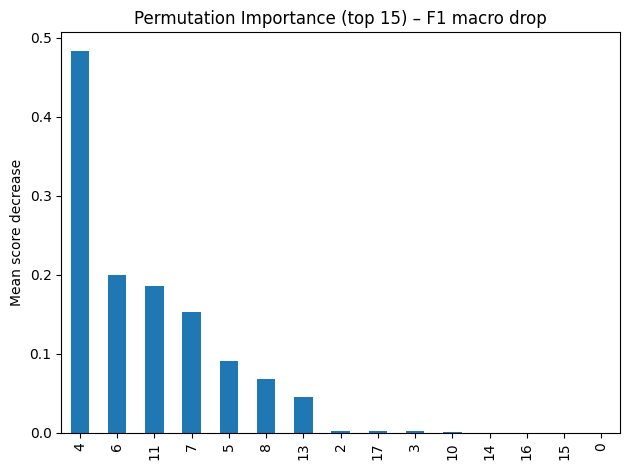

In [18]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

r = permutation_importance(
    best_pipe, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1, scoring='f1_macro'
)

# Pipeline ke one-hot ki wajah se feature names expand hote hain; simple view: top 15 raw importances
importances = pd.Series(r.importances_mean).sort_values(ascending=False)[:15]

plt.figure()
importances.plot(kind='bar')
plt.title("Permutation Importance (top 15) – F1 macro drop")
plt.ylabel("Mean score decrease")
plt.tight_layout()
plt.show()


# Clinic-wise evaluation

In [19]:

from sklearn.metrics import accuracy_score, f1_score

# yeh assume karta hai: original cleaned df (df) me 'clinic_id' aur split ke masks mil jaayen
# Test subset ka mask:
test_idx = X_test.index
df_test = df.loc[test_idx].copy()

rows = []
for clinic in df_test['clinic_id'].unique():
    mask = (df_test['clinic_id'] == clinic)
    if mask.sum() < 10:  # tiny group skip
        continue
    y_true_c = y_test[mask]
    y_pred_c = best_pipe.predict(X_test[mask])
    rows.append({
        "clinic_id": clinic,
        "n": mask.sum(),
        "acc": accuracy_score(y_true_c, y_pred_c),
        "f1_macro": f1_score(y_true_c, y_pred_c, average='macro')
    })

clinic_metrics = pd.DataFrame(rows).sort_values("f1_macro", ascending=False)
clinic_metrics


,clinic_id,n,acc,f1_macro
2,HH-ND,178,0.988764,0.988969
0,HH-DW,293,0.989761,0.988412
1,HH-GK,501,0.994012,0.983647


# Quick Error Analysis

In [20]:

labels = sorted(y.unique())

y_pred_best = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best, labels=labels)

print("Labels:", labels)
print(cm)

# Sabse zyada confusion wale pairs:
import itertools
pairs = []
for i, j in itertools.product(range(len(labels)), range(len(labels))):
    if i != j and cm[i, j] > 0:
        pairs.append((labels[i], labels[j], cm[i, j]))
pairs_sorted = sorted(pairs, key=lambda x: -x[2])[:5]
print("Top confusions (true -> pred, count):", pairs_sorted)


Labels: ['ConsiderHearingAid', 'FollowExercises', 'Maintain', 'ScheduleCheckup', 'UseProtection']
[[141   0   2   0   0]
 [  0  22   1   0   0]
 [  0   0 661   4   1]
 [  0   0   0  76   0]
 [  0   0   0   0  64]]
Top confusions (true -> pred, count): [('Maintain', 'ScheduleCheckup', 4), ('ConsiderHearingAid', 'Maintain', 2), ('FollowExercises', 'Maintain', 1), ('Maintain', 'UseProtection', 1)]


# Save final pipeline as pickle

In [21]:
import joblib
joblib.dump(best_pipe, "hearinghope_pipeline.pkl")
print("✅ Saved best pipeline as hearinghope_pipeline.pkl (", best_name, ")")


✅ Saved best pipeline as hearinghope_pipeline.pkl ( GradientBoosting )


# Quick demo prediction

In [22]:


import pandas as pd

sample = {
    "clinic_id": "HH-GK",
    "city": "New Delhi",
    "gender": "M",
    "occupation_noise_risk": "High",
    "hearing_aid_brand": "Signia",
    "smoking_status": "Never",
    "age": 60,
    "pure_tone_avg_db": 48.0,
    "speech_recognition_score": 55.0,
    "hours_noisy_per_day": 4.5,
    "hearing_aid_use": 0,
    "hearing_aid_hours": 0,
    "hearing_difficulty_score": 8,
    "followup_last_months": 18,
    "engages_exercises": 0,
    "tinnitus": 1,
    "prior_ear_infections": 0,
    "diabetes": 0
}

print("Final Recommendation:", best_pipe.predict(pd.DataFrame([sample]))[0])



Final Recommendation: ConsiderHearingAid
